# 03. Альтернативний аналіз: розподіл ЗВО за кількістю студентів

Мета ноутбука - взяти дані про кількість студентів для всіх країн ETER і побудувати гістограму відносних частот. Це дає змогу побачити форму розподілу закладів за розміром без прив'язки до абсолютної кількості спостережень.


## 1. Імпорт бібліотек і налаштування

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "df_base_clean.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


NOTEBOOK_PREFIX = "03_"


def save_figure(filename, fig=None, dpi=200):
    normalized_name = filename if filename.startswith(NOTEBOOK_PREFIX) else f"{NOTEBOOK_PREFIX}{filename}"
    figure = fig if fig is not None else plt.gcf()
    path = FIGURES_DIR / normalized_name
    figure.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

DATA_PATH

PosixPath('/Users/ssyvon41kkk/PycharmProjects/ETER.EDBO.v2/data/processed/df_base_clean.csv')

## 2. Завантаження очищених даних

Використовується `df_base_clean.csv`, підготовлений на попередніх етапах. Аналіз проводиться на рівні спостереження ЗВО-рік.


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Не найден файл: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()

Rows: 29,591
Columns: 57


,record_id,institution_id,institution_name,institution_name_en,year,country_code,nuts2,nuts3,city,latitude,...,flag_foreign_students_isced7_long_degree,flag_foreign_students_isced5_7_total,flag_foreign_students_isced8,flag_academic_personnel_fte,flag_total_personnel_fte,flag_support_admin_personnel_fte,flag_total_current_expenditure,flag_total_current_revenues,flag_third_party_funding,flag_rd_expenditure
0,AD0001.2023,AD0001,Universitat d'Andorra,University of Andorra,2023,AD,AD00,AD000,Sant Julià de Lòria,42.463227,...,NaN,NaN,NaN,NaN,NaN,NaN,d,NaN,NaN,NaN
1,AL0001.2023,AL0001,Universiteti i Tiranës,University of Tirana,2023,AL,AL02,AL022,Tirana,41.318093,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AL0002.2023,AL0002,Universiteti Politeknik i Tiranës,Polytechnic University of Tirana,2023,AL,AL02,AL022,Tirana,41.316598,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AL0003.2023,AL0003,Universiteti Bujqësor i Tiranës,Agricultural University of Tirana,2023,AL,AL02,AL022,Tirana,41.363000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AL0004.2023,AL0004,"Universiteti i Elbasanit ""Aleksandër Xhuvani""","University of Elbasan, Aleksander Xhuvani",2023,AL,AL02,AL021,Elbasan,41.122408,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info(verbose=False)

<class 'pandas.DataFrame'>
RangeIndex: 29591 entries, 0 to 29590
Columns: 57 entries, record_id to flag_rd_expenditure
dtypes: float64(28), int64(1), str(28)
memory usage: 12.9 MB


## 3. Підготовка показника кількості студентів

У `df_base_clean.csv` немає готової колонки `students_total_calc`, тому вона розраховується як сума студентів ISCED 5-7 total та ISCED 8. Якщо значення ISCED 5-7 total відсутнє, використовується сума доступних ISCED 5, 6, 7 і 7 long degree.


In [5]:
required_cols = [
    "country_code",
    "year",
    "institution_id",
    "institution_name_en",
    "students_isced5_7_total",
    "students_isced5",
    "students_isced6",
    "students_isced7",
    "students_isced7_long_degree",
    "students_isced8",
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise KeyError(f"В df_base_clean.csv отсутствуют нужные колонки: {missing_cols}")

student_cols = [
    "students_isced5_7_total",
    "students_isced5",
    "students_isced6",
    "students_isced7",
    "students_isced7_long_degree",
    "students_isced8",
]

for col in student_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

isced_5_7_fallback = df[[
    "students_isced5",
    "students_isced6",
    "students_isced7",
    "students_isced7_long_degree",
]].sum(axis=1, min_count=1)

students_5_7 = df["students_isced5_7_total"].combine_first(isced_5_7_fallback)
df["students_total_calc"] = students_5_7.add(df["students_isced8"].fillna(0), fill_value=np.nan)

df[["students_isced5_7_total", "students_isced8", "students_total_calc"]].describe()

,students_isced5_7_total,students_isced8,students_total_calc
count,2.615800e+04,24971.000000,2.752300e+04
mean,9.613587e+03,310.465083,9.445185e+03
std,6.082023e+04,770.581991,5.947821e+04
min,0.000000e+00,0.000000,0.000000e+00
25%,6.740000e+02,0.000000,5.808333e+02
50%,2.779090e+03,0.000000,2.465000e+03
75%,1.076150e+04,236.000000,1.047450e+04
max,3.536929e+06,9728.000000,3.538594e+06


## 4. Фільтрація спостережень

Правила фільтрації:

- використовуються всі країни з очищеного ETER-набору;
- одиниця спостереження - `institution_id + year`;
- виключаються рядки без розрахованої кількості студентів;
- виключаються рядки з нульовою або від'ємною кількістю студентів;
- країни агреговано не зважуються, тому країни з більшою кількістю ЗВО-років дають більше спостережень у загальній гістограмі.


In [6]:
students_df = df.loc[
    df["students_total_calc"].notna() & (df["students_total_calc"] > 0),
    ["country_code", "year", "institution_id", "institution_name_en", "students_total_calc"],
].copy()

exclusions = pd.DataFrame(
    {
        "rule": [
            "missing_students_total_calc",
            "zero_or_negative_students_total_calc",
            "included_positive_students_total_calc",
        ],
        "rows": [
            df["students_total_calc"].isna().sum(),
            (df["students_total_calc"].notna() & (df["students_total_calc"] <= 0)).sum(),
            len(students_df),
        ],
    }
)

exclusions

,rule,rows
0,missing_students_total_calc,2068
1,zero_or_negative_students_total_calc,890
2,included_positive_students_total_calc,26633


In [7]:
coverage_summary = pd.Series(
    {
        "observations": len(students_df),
        "countries": students_df["country_code"].nunique(),
        "years": students_df["year"].nunique(),
        "institutions": students_df["institution_id"].nunique(),
        "min_year": students_df["year"].min(),
        "max_year": students_df["year"].max(),
    }
)

coverage_summary

observations    26633
countries          39
years              11
institutions     3861
min_year         2013
max_year         2023
dtype: int64

## 5. Описова статистика

In [8]:
students_df["students_total_calc"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name="students_total_calc")

,students_total_calc
count,2.663300e+04
mean,9.760816e+03
std,6.043840e+04
min,3.000000e+00
1%,4.500000e+01
5%,1.750000e+02
10%,2.800000e+02
25%,6.650000e+02
50%,2.726000e+03
75%,1.089400e+04


## 6. Гістограма відносних частот

`stat="probability"` нормує висоту стовпчиків так, щоб сума відносних частот за всіма бінами дорівнювала 1. У цій версії біни рівні у звичайній лінійній шкалі.


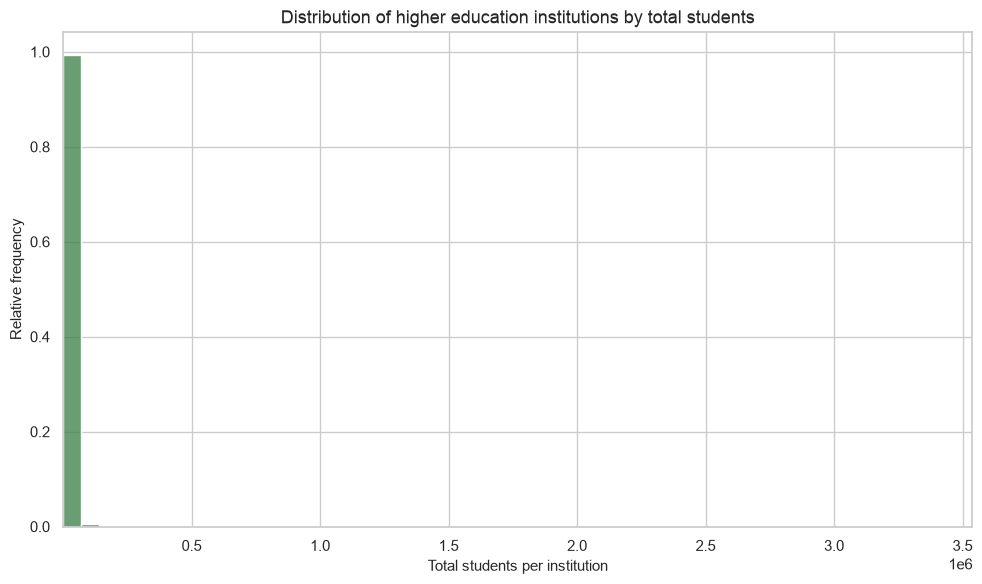

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=students_df,
    x="students_total_calc",
    bins=50,
    stat="probability",
    color="#3A7D44",
    edgecolor="white",
    ax=ax,
)

ax.set_title("Distribution of higher education institutions by total students")
ax.set_xlabel("Total students per institution")
ax.set_ylabel("Relative frequency")
ax.margins(x=0)

plt.tight_layout()
save_figure("03_students_total_distribution.png", fig=fig)
plt.show()

## 7. Гістограма з рівними інтервалами в логарифмічній шкалі

Розподіл розміру ЗВО зазвичай має довгий правий хвіст: багато малих і середніх закладів та невелика кількість дуже великих. Тому для основної версії нижче використовуються 50 інтервалів, рівних не у вихідній шкалі студентів, а в логарифмічній шкалі `log10(students_total_calc)`. Поверх загальної гістограми додано верхні контури розподілів Франції (`country_code == "FR"`), Польщі (`country_code == "PL"`) та Сполученого Королівства (`country_code == "UK"`) за тими самими логарифмічними інтервалами.


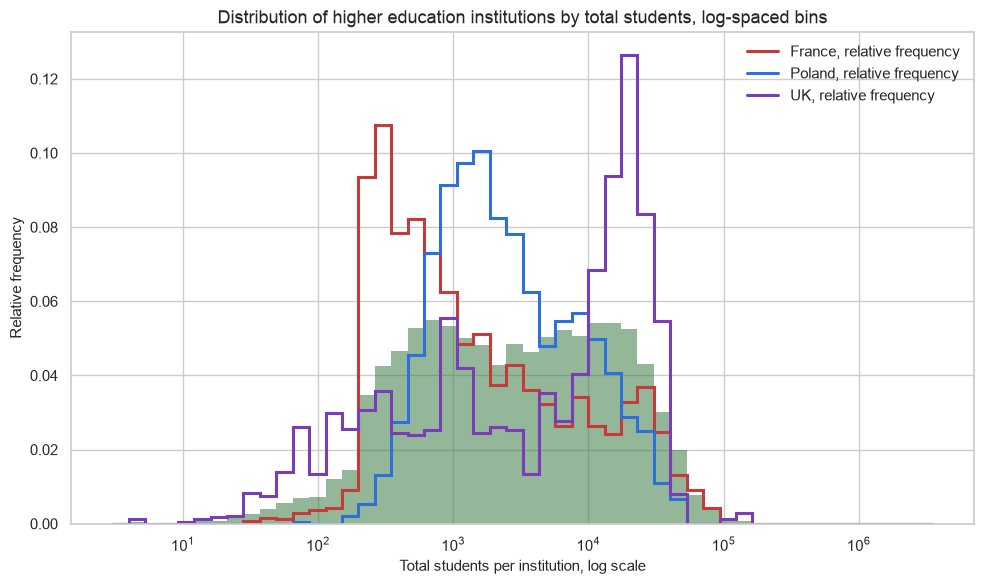

In [10]:
n_bins = 50
min_students = students_df["students_total_calc"].min()
max_students = students_df["students_total_calc"].max()
log_bins = np.logspace(np.log10(min_students), np.log10(max_students), n_bins + 1)
france_df = students_df.loc[students_df["country_code"] == "FR"].copy()
poland_df = students_df.loc[students_df["country_code"] == "PL"].copy()
uk_df = students_df.loc[students_df["country_code"] == "UK"].copy()

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=students_df,
    x="students_total_calc",
    bins=log_bins,
    stat="probability",
    color="#3A7D44",
    alpha=0.55,
    edgecolor="white",
    ax=ax,
)

fr_counts, _ = np.histogram(france_df["students_total_calc"], bins=log_bins)
fr_relative_freq = fr_counts / fr_counts.sum()
ax.stairs(
    fr_relative_freq,
    log_bins,
    baseline=None,
    color="#C43B3B",
    linewidth=2.2,
    label="France, relative frequency",
)

pl_counts, _ = np.histogram(poland_df["students_total_calc"], bins=log_bins)
pl_relative_freq = pl_counts / pl_counts.sum()
ax.stairs(
    pl_relative_freq,
    log_bins,
    baseline=None,
    color="#2F6FDB",
    linewidth=2.2,
    label="Poland, relative frequency",
)

uk_counts, _ = np.histogram(uk_df["students_total_calc"], bins=log_bins)
uk_relative_freq = uk_counts / uk_counts.sum()
ax.stairs(
    uk_relative_freq,
    log_bins,
    baseline=None,
    color="#7A3DB8",
    linewidth=2.2,
    label="UK, relative frequency",
)

ax.set_xscale("log")
ax.set_title("Distribution of higher education institutions by total students, log-spaced bins")
ax.set_xlabel("Total students per institution, log scale")
ax.set_ylabel("Relative frequency")
ax.legend(frameon=False)

plt.tight_layout()
save_figure("03_students_total_distribution_log_bins_country_overlay.png", fig=fig)
plt.show()

## 8. Контроль за країнами

Таблиця нижче показує, скільки спостережень по кожній країні потрапило в розрахунок. Вона потрібна для інтерпретації загальної гістограми: країни представлені в ній не з однаковою вагою, а пропорційно до кількості доступних ЗВО-років.


In [11]:
country_observations = (
    students_df.groupby("country_code", as_index=False)
    .agg(
        observations=("students_total_calc", "size"),
        institutions=("institution_id", "nunique"),
        years=("year", "nunique"),
        median_students=("students_total_calc", "median"),
        mean_students=("students_total_calc", "mean"),
    )
    .sort_values("observations", ascending=False)
)

country_observations.head(20)

,country_code,observations,institutions,years,median_students,mean_students
8,DE,3952,420,10,2923.000000,7203.581984
13,FR,2437,968,7,962.000000,5978.828888
37,UK,2381,282,10,6040.000000,10797.024360
29,PL,2290,309,9,2140.000000,5285.574236
19,IT,2094,221,10,925.000000,9427.571633
36,TR,1924,221,10,13210.500000,38337.488565
30,PT,917,113,10,1335.000000,4132.941112
11,ES,843,91,10,13570.000000,19354.502966
2,AT,739,76,11,1941.115513,5338.729650
7,CZ,619,75,10,1416.000000,5111.323102


## 9. Кількість студентів на викладача за країною та групою ЗВО, останній доступний рік

Таблиця нижче повторює логіку `median_students_by_country_group_wide_latest_year.csv`, але замість медіанної кількості студентів рахує медіанну кількість студентів на одного викладача. Показник розраховується на рівні ЗВО-року як `students_total_calc / academic_personnel_fte`. Для кожної країни та кожної групи ЗВО береться останній рік, де є валідні студенти й додатне значення `academic_personnel_fte`; тому окремі комірки можуть використовувати різні останні доступні роки.


In [12]:
ratio_required_cols = [
    "country_code",
    "year",
    "institution_id",
    "students_total_calc",
    "academic_personnel_fte",
    "legal_status",
    "institution_category_std",
]

missing_ratio_cols = [col for col in ratio_required_cols if col not in df.columns]
if missing_ratio_cols:
    raise KeyError(f"В df_base_clean.csv отсутствуют нужные колонки: {missing_ratio_cols}")

for col in ["academic_personnel_fte", "legal_status", "institution_category_std"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

teacher_ratio_exclusions = pd.DataFrame(
    {
        "rule": [
            "missing_students_total_calc",
            "zero_or_negative_students_total_calc",
            "missing_academic_personnel_fte",
            "zero_or_negative_academic_personnel_fte",
            "included_positive_students_and_academic_personnel",
        ],
        "rows": [
            df["students_total_calc"].isna().sum(),
            (df["students_total_calc"].notna() & (df["students_total_calc"] <= 0)).sum(),
            df["academic_personnel_fte"].isna().sum(),
            (df["academic_personnel_fte"].notna() & (df["academic_personnel_fte"] <= 0)).sum(),
            (
                df["students_total_calc"].notna()
                & (df["students_total_calc"] > 0)
                & df["academic_personnel_fte"].notna()
                & (df["academic_personnel_fte"] > 0)
            ).sum(),
        ],
    }
)

teacher_ratio_df = df.loc[
    df["students_total_calc"].notna()
    & (df["students_total_calc"] > 0)
    & df["academic_personnel_fte"].notna()
    & (df["academic_personnel_fte"] > 0),
    [
        "country_code",
        "year",
        "institution_id",
        "students_total_calc",
        "academic_personnel_fte",
        "legal_status",
        "institution_category_std",
    ],
].copy()

teacher_ratio_df["students_per_teacher"] = (
    teacher_ratio_df["students_total_calc"] / teacher_ratio_df["academic_personnel_fte"]
)

reference_table_path = PROJECT_ROOT / "data" / "processed" / "median_students_by_country_group_wide_latest_year.csv"
if reference_table_path.exists():
    reference_country_codes = (
        pd.read_csv(reference_table_path, sep=";")["country_code"]
        .dropna()
        .astype(str)
        .loc[lambda codes: ~codes.str.startswith("*")]
        .tolist()
    )
else:
    reference_country_codes = sorted(df["country_code"].dropna().astype(str).unique())

# ETER coding used in the cleaned dataset: legal_status 0 = public, 1 = private, 2 = other;
# institution_category_std 1 = university, 2 = university of applied sciences, 0 = other HEI.
group_definitions = {
    "all_heis": lambda data: pd.Series(True, index=data.index),
    "all_private_heis": lambda data: data["legal_status"].eq(1),
    "all_public_heis": lambda data: data["legal_status"].eq(0),
    "other_heis": lambda data: data["institution_category_std"].eq(0),
    "private_universities": lambda data: data["legal_status"].eq(1)
    & data["institution_category_std"].eq(1),
    "private_universities_of_applied_sciences": lambda data: data["legal_status"].eq(1)
    & data["institution_category_std"].eq(2),
    "public_universities": lambda data: data["legal_status"].eq(0)
    & data["institution_category_std"].eq(1),
    "public_universities_of_applied_sciences": lambda data: data["legal_status"].eq(0)
    & data["institution_category_std"].eq(2),
    "universities": lambda data: data["institution_category_std"].eq(1),
    "universities_of_applied_sciences": lambda data: data["institution_category_std"].eq(2),
}

teacher_ratio_wide = pd.DataFrame({"country_code": reference_country_codes})
teacher_ratio_years_wide = pd.DataFrame({"country_code": reference_country_codes})

for group_name, group_mask_func in group_definitions.items():
    group_data = teacher_ratio_df.loc[group_mask_func(teacher_ratio_df)].copy()

    if group_data.empty:
        teacher_ratio_wide[group_name] = np.nan
        teacher_ratio_years_wide[group_name] = np.nan
        continue

    group_latest_year = group_data.groupby("country_code")["year"].max().rename("latest_year")
    group_latest_data = group_data.merge(group_latest_year, on="country_code")
    group_latest_data = group_latest_data.loc[
        group_latest_data["year"] == group_latest_data["latest_year"]
    ].copy()

    group_median = (
        group_latest_data.groupby("country_code")["students_per_teacher"]
        .median()
        .rename(group_name)
        .reset_index()
    )
    group_year = group_latest_year.rename(group_name).reset_index()

    teacher_ratio_wide = teacher_ratio_wide.merge(group_median, on="country_code", how="left")
    teacher_ratio_years_wide = teacher_ratio_years_wide.merge(group_year, on="country_code", how="left")

output_path = PROJECT_ROOT / "data" / "processed" / "students_per_teacher_by_country_group_wide_latest_year.csv"
years_output_path = PROJECT_ROOT / "data" / "processed" / "students_per_teacher_by_country_group_years_wide.csv"
teacher_ratio_wide.to_csv(output_path, sep=";", decimal=",", index=False, float_format="%.2f")
teacher_ratio_years_wide.to_csv(years_output_path, sep=";", index=False, float_format="%.0f")

teacher_ratio_coverage = pd.Series(
    {
        "observations": len(teacher_ratio_df),
        "countries_in_reference_table": len(reference_country_codes),
        "countries_with_any_valid_ratio": teacher_ratio_df["country_code"].nunique(),
        "countries_without_valid_ratio": ", ".join(
            sorted(set(reference_country_codes) - set(teacher_ratio_df["country_code"].dropna().astype(str)))
        ),
        "institutions": teacher_ratio_df["institution_id"].nunique(),
        "min_year_used": int(teacher_ratio_years_wide.drop(columns="country_code").min().min()),
        "max_year_used": int(teacher_ratio_years_wide.drop(columns="country_code").max().max()),
        "output_path": str(output_path.relative_to(PROJECT_ROOT)),
        "years_output_path": str(years_output_path.relative_to(PROJECT_ROOT)),
    }
)

teacher_ratio_exclusions, teacher_ratio_coverage, teacher_ratio_wide.head()


(                                                rule   rows
 0                        missing_students_total_calc   2068
 1               zero_or_negative_students_total_calc    890
 2                     missing_academic_personnel_fte  12896
 3            zero_or_negative_academic_personnel_fte    100
 4  included_positive_students_and_academic_personnel  16565,
 observations                                                                  16565
 countries_in_reference_table                                                     40
 countries_with_any_valid_ratio                                                   34
 countries_without_valid_ratio                                AD, AL, ME, TR, VA, XK
 institutions                                                                   2432
 min_year_used                                                                  2014
 max_year_used                                                                  2023
 output_path                       dat

### Гістограма кількості студентів на викладача

Графік нижче будується за даними пункту 9 і повторює логіку гістограми вище: загальний фон для всіх доступних спостережень і контури тих самих країн тими самими кольорами.


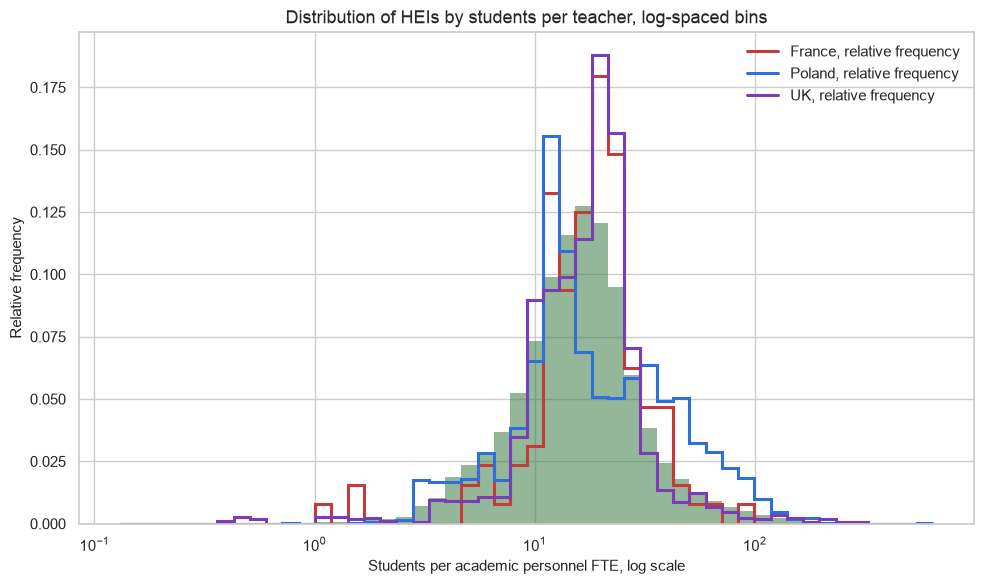

In [13]:
ratio_hist_df = teacher_ratio_df.loc[
    teacher_ratio_df["students_per_teacher"].notna()
    & np.isfinite(teacher_ratio_df["students_per_teacher"])
    & (teacher_ratio_df["students_per_teacher"] > 0)
].copy()

ratio_n_bins = 50
ratio_min = ratio_hist_df["students_per_teacher"].min()
ratio_max = ratio_hist_df["students_per_teacher"].max()
ratio_log_bins = np.logspace(np.log10(ratio_min), np.log10(ratio_max), ratio_n_bins + 1)

country_color_map = {
    "FR": ("France", "#C43B3B"),
    "PL": ("Poland", "#2F6FDB"),
    "UK": ("UK", "#7A3DB8"),
}

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=ratio_hist_df,
    x="students_per_teacher",
    bins=ratio_log_bins,
    stat="probability",
    color="#3A7D44",
    alpha=0.55,
    edgecolor="white",
    ax=ax,
)

for country_code, (country_label, country_color) in country_color_map.items():
    country_values = ratio_hist_df.loc[
        ratio_hist_df["country_code"] == country_code,
        "students_per_teacher",
    ]
    if country_values.empty:
        continue

    country_counts, _ = np.histogram(country_values, bins=ratio_log_bins)
    country_relative_freq = country_counts / country_counts.sum()
    ax.stairs(
        country_relative_freq,
        ratio_log_bins,
        baseline=None,
        color=country_color,
        linewidth=2.2,
        label=f"{country_label}, relative frequency",
    )

ax.set_xscale("log")
ax.set_title("Distribution of HEIs by students per teacher, log-spaced bins")
ax.set_xlabel("Students per academic personnel FTE, log scale")
ax.set_ylabel("Relative frequency")
ax.legend(frameon=False)

plt.tight_layout()
save_figure("03_students_per_teacher_distribution_log_bins_country_overlay.png", fig=fig)
plt.show()


## 10. Коротка інтерпретація

- Гістограма відносних частот показує розподіл розміру ЗВО серед усіх доступних спостережень ETER.
- Якщо графік має довгий правий хвіст, це означає, що більшість закладів малі або середні, а дуже великі ЗВО трапляються порівняно рідко.
- Версія в логарифмічній шкалі важлива для читання розподілу, бо великі заклади можуть стискати основну масу спостережень на звичайній шкалі.
- Загальна гістограма не є збалансованою за країнами: країни з більшою кількістю закладів і років сильніше впливають на форму розподілу.
- Таблиця `students_per_teacher_by_country_group_wide_latest_year.csv` показує медіанне значення на рівні закладів; для кожної країни та групи ЗВО береться останній рік, де доступні і студенти, і `academic_personnel_fte`.
- Для країн без додатного `academic_personnel_fte` в усіх доступних роках показник не розраховується й залишається пропущеним.
- Результат описовий; він не пояснює причини відмінностей і має інтерпретуватися з урахуванням обмежень ETER, пропусків і національних правил обліку.


## 11. Освітнє фінансування на студента за країною та групою ЗВО, останній доступний рік

Таблиця нижче повторює структуру пункту 9: рядки - країни, стовпці - ті самі групи ЗВО, значення - медіана на рівні закладів за останній доступний рік для кожної країни та групи. Показник розраховується як **освітнє фінансування на одного студента**. В очищеному ETER-наборі немає окремої колонки `education_funding`, тому використовується `total_current_expenditure_eur` як проксі поточного освітнього фінансування закладу; додатково розраховується PPP-версія на основі `total_current_expenditure_ppp` для коректнішого міжкраїнного читання.


In [14]:
education_funding_required_cols = [
    "country_code",
    "year",
    "institution_id",
    "students_total_calc",
    "total_current_expenditure_eur",
    "legal_status",
    "institution_category_std",
]

education_funding_optional_cols = ["total_current_expenditure_ppp"]

missing_education_funding_cols = [
    col for col in education_funding_required_cols if col not in df.columns
]
if missing_education_funding_cols:
    raise KeyError(
        "В df_base_clean.csv отсутствуют нужные колонки: "
        f"{missing_education_funding_cols}"
    )

available_education_funding_optional_cols = [
    col for col in education_funding_optional_cols if col in df.columns
]

numeric_education_funding_cols = [
    "students_total_calc",
    "total_current_expenditure_eur",
    "legal_status",
    "institution_category_std",
] + available_education_funding_optional_cols

for col in numeric_education_funding_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

education_funding_exclusions = pd.DataFrame(
    {
        "rule": [
            "missing_students_total_calc",
            "zero_or_negative_students_total_calc",
            "missing_education_funding_eur",
            "zero_or_negative_education_funding_eur",
            "included_positive_students_and_education_funding_eur",
        ],
        "rows": [
            df["students_total_calc"].isna().sum(),
            (df["students_total_calc"].notna() & (df["students_total_calc"] <= 0)).sum(),
            df["total_current_expenditure_eur"].isna().sum(),
            (
                df["total_current_expenditure_eur"].notna()
                & (df["total_current_expenditure_eur"] <= 0)
            ).sum(),
            (
                df["students_total_calc"].notna()
                & (df["students_total_calc"] > 0)
                & df["total_current_expenditure_eur"].notna()
                & (df["total_current_expenditure_eur"] > 0)
            ).sum(),
        ],
    }
)

education_funding_selected_cols = education_funding_required_cols + available_education_funding_optional_cols

education_funding_df = df.loc[
    df["students_total_calc"].notna()
    & (df["students_total_calc"] > 0)
    & df["total_current_expenditure_eur"].notna()
    & (df["total_current_expenditure_eur"] > 0),
    education_funding_selected_cols,
].copy()

education_funding_df["education_funding_per_student_eur"] = (
    education_funding_df["total_current_expenditure_eur"]
    / education_funding_df["students_total_calc"]
)

if "total_current_expenditure_ppp" in education_funding_df.columns:
    education_funding_df["education_funding_per_student_ppp"] = np.where(
        education_funding_df["total_current_expenditure_ppp"].notna()
        & (education_funding_df["total_current_expenditure_ppp"] > 0),
        education_funding_df["total_current_expenditure_ppp"]
        / education_funding_df["students_total_calc"],
        np.nan,
    )

try:
    reference_country_codes
except NameError:
    reference_table_path = (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "median_students_by_country_group_wide_latest_year.csv"
    )
    if reference_table_path.exists():
        reference_country_codes = (
            pd.read_csv(reference_table_path, sep=";")["country_code"]
            .dropna()
            .astype(str)
            .loc[lambda codes: ~codes.str.startswith("*")]
            .tolist()
        )
    else:
        reference_country_codes = sorted(df["country_code"].dropna().astype(str).unique())

try:
    group_definitions
except NameError:
    # ETER coding used in the cleaned dataset: legal_status 0 = public, 1 = private, 2 = other;
    # institution_category_std 1 = university, 2 = university of applied sciences, 0 = other HEI.
    group_definitions = {
        "all_heis": lambda data: pd.Series(True, index=data.index),
        "all_private_heis": lambda data: data["legal_status"].eq(1),
        "all_public_heis": lambda data: data["legal_status"].eq(0),
        "other_heis": lambda data: data["institution_category_std"].eq(0),
        "private_universities": lambda data: data["legal_status"].eq(1)
        & data["institution_category_std"].eq(1),
        "private_universities_of_applied_sciences": lambda data: data["legal_status"].eq(1)
        & data["institution_category_std"].eq(2),
        "public_universities": lambda data: data["legal_status"].eq(0)
        & data["institution_category_std"].eq(1),
        "public_universities_of_applied_sciences": lambda data: data["legal_status"].eq(0)
        & data["institution_category_std"].eq(2),
        "universities": lambda data: data["institution_category_std"].eq(1),
        "universities_of_applied_sciences": lambda data: data["institution_category_std"].eq(2),
    }


def build_latest_year_group_wide(data, value_col):
    wide = pd.DataFrame({"country_code": reference_country_codes})
    years_wide = pd.DataFrame({"country_code": reference_country_codes})

    valid_data = data.loc[
        data[value_col].notna()
        & np.isfinite(data[value_col])
        & (data[value_col] > 0)
    ].copy()

    for group_name, group_mask_func in group_definitions.items():
        group_data = valid_data.loc[group_mask_func(valid_data)].copy()

        if group_data.empty:
            wide[group_name] = np.nan
            years_wide[group_name] = np.nan
            continue

        group_latest_year = group_data.groupby("country_code")["year"].max().rename("latest_year")
        group_latest_data = group_data.merge(group_latest_year, on="country_code")
        group_latest_data = group_latest_data.loc[
            group_latest_data["year"] == group_latest_data["latest_year"]
        ].copy()

        group_median = (
            group_latest_data.groupby("country_code")[value_col]
            .median()
            .rename(group_name)
            .reset_index()
        )
        group_year = group_latest_year.rename(group_name).reset_index()

        wide = wide.merge(group_median, on="country_code", how="left")
        years_wide = years_wide.merge(group_year, on="country_code", how="left")

    return wide, years_wide


def year_range(years_wide):
    values = years_wide.drop(columns="country_code").stack().dropna()
    if values.empty:
        return pd.Series({"min_year_used": np.nan, "max_year_used": np.nan})
    return pd.Series(
        {
            "min_year_used": int(values.min()),
            "max_year_used": int(values.max()),
        }
    )


education_funding_wide, education_funding_years_wide = build_latest_year_group_wide(
    education_funding_df,
    "education_funding_per_student_eur",
)

education_funding_output_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "education_funding_per_student_by_country_group_wide_latest_year.csv"
)
education_funding_years_output_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "education_funding_per_student_by_country_group_years_wide.csv"
)

education_funding_wide.to_csv(
    education_funding_output_path,
    sep=";",
    decimal=",",
    index=False,
    float_format="%.2f",
)
education_funding_years_wide.to_csv(
    education_funding_years_output_path,
    sep=";",
    index=False,
    float_format="%.0f",
)

ppp_outputs = {}
if "education_funding_per_student_ppp" in education_funding_df.columns:
    education_funding_ppp_wide, education_funding_ppp_years_wide = build_latest_year_group_wide(
        education_funding_df,
        "education_funding_per_student_ppp",
    )

    education_funding_ppp_output_path = (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "education_funding_per_student_ppp_by_country_group_wide_latest_year.csv"
    )
    education_funding_ppp_years_output_path = (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "education_funding_per_student_ppp_by_country_group_years_wide.csv"
    )

    education_funding_ppp_wide.to_csv(
        education_funding_ppp_output_path,
        sep=";",
        decimal=",",
        index=False,
        float_format="%.2f",
    )
    education_funding_ppp_years_wide.to_csv(
        education_funding_ppp_years_output_path,
        sep=";",
        index=False,
        float_format="%.0f",
    )

    ppp_outputs = {
        "ppp_output_path": str(education_funding_ppp_output_path.relative_to(PROJECT_ROOT)),
        "ppp_years_output_path": str(
            education_funding_ppp_years_output_path.relative_to(PROJECT_ROOT)
        ),
        "countries_with_any_valid_ppp": education_funding_df.loc[
            education_funding_df["education_funding_per_student_ppp"].notna(),
            "country_code",
        ].nunique(),
    }

education_year_range = year_range(education_funding_years_wide)

education_funding_coverage = pd.Series(
    {
        "observations": len(education_funding_df),
        "countries_in_reference_table": len(reference_country_codes),
        "countries_with_any_valid_education_funding": education_funding_df["country_code"].nunique(),
        "countries_without_valid_education_funding": ", ".join(
            sorted(
                set(reference_country_codes)
                - set(education_funding_df["country_code"].dropna().astype(str))
            )
        ),
        "institutions": education_funding_df["institution_id"].nunique(),
        "min_year_used": education_year_range["min_year_used"],
        "max_year_used": education_year_range["max_year_used"],
        "education_funding_source_eur": "total_current_expenditure_eur",
        "education_funding_source_ppp": "total_current_expenditure_ppp"
        if "total_current_expenditure_ppp" in education_funding_df.columns
        else np.nan,
        "output_path": str(education_funding_output_path.relative_to(PROJECT_ROOT)),
        "years_output_path": str(education_funding_years_output_path.relative_to(PROJECT_ROOT)),
        **ppp_outputs,
    }
)

education_funding_exclusions, education_funding_coverage, education_funding_wide.head()



(                                                rule   rows
 0                        missing_students_total_calc   2068
 1               zero_or_negative_students_total_calc    890
 2                      missing_education_funding_eur  16586
 3             zero_or_negative_education_funding_eur     65
 4  included_positive_students_and_education_fundi...  12598,
 observations                                                                              12598
 countries_in_reference_table                                                                 40
 countries_with_any_valid_education_funding                                                   30
 countries_without_valid_education_funding                AL, BG, ES, GR, HR, MK, RS, SI, VA, XK
 institutions                                                                               1798
 min_year_used                                                                              2014
 max_year_used                                     

### Гістограма освітнього фінансування на студента

Графік нижче будується за даними пункту 11 і повторює логіку попередніх гістограм: загальний фон для всіх доступних спостережень і контури Франції, Польщі та UK тими самими кольорами. Використовується номінальний показник `education_funding_per_student_eur`, тому міжкраїнні відмінності потрібно читати обережно; для порівняння країн бажано використовувати PPP-версію таблиці.


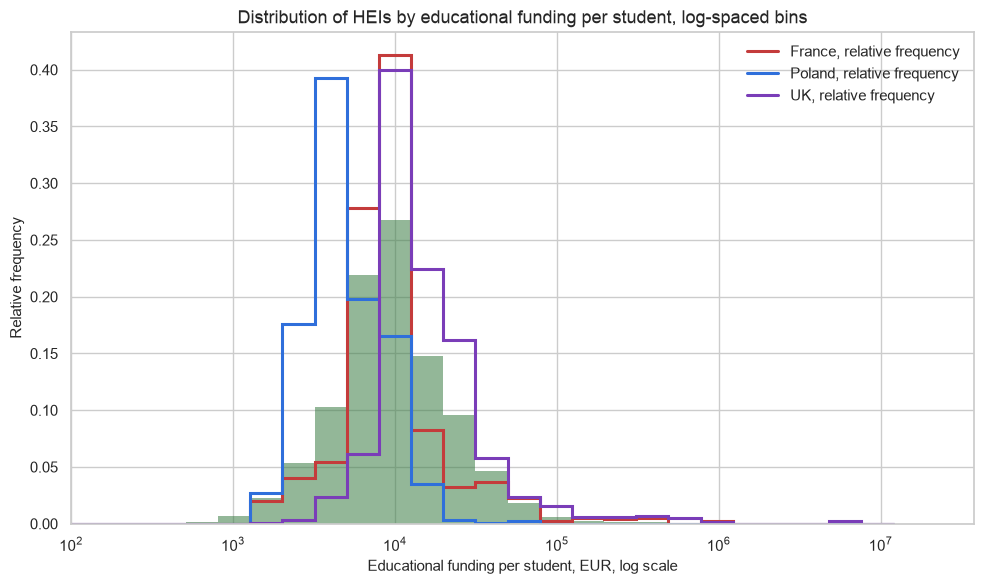

In [15]:
funding_hist_df = education_funding_df.loc[
    education_funding_df["education_funding_per_student_eur"].notna()
    & np.isfinite(education_funding_df["education_funding_per_student_eur"])
    & (education_funding_df["education_funding_per_student_eur"] > 0)
].copy()

funding_n_bins = 50
funding_min = funding_hist_df["education_funding_per_student_eur"].min()
funding_max = funding_hist_df["education_funding_per_student_eur"].max()
funding_log_bins = np.logspace(np.log10(funding_min), np.log10(funding_max), funding_n_bins + 1)

try:
    country_color_map
except NameError:
    country_color_map = {
        "FR": ("France", "#C43B3B"),
        "PL": ("Poland", "#2F6FDB"),
        "UK": ("UK", "#7A3DB8"),
    }

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=funding_hist_df,
    x="education_funding_per_student_eur",
    bins=funding_log_bins,
    stat="probability",
    color="#3A7D44",
    alpha=0.55,
    edgecolor="white",
    ax=ax,
)

for country_code, (country_label, country_color) in country_color_map.items():
    country_values = funding_hist_df.loc[
        funding_hist_df["country_code"] == country_code,
        "education_funding_per_student_eur",
    ]
    if country_values.empty:
        continue

    country_counts, _ = np.histogram(country_values, bins=funding_log_bins)
    country_relative_freq = country_counts / country_counts.sum()
    ax.stairs(
        country_relative_freq,
        funding_log_bins,
        baseline=None,
        color=country_color,
        linewidth=2.2,
        label=f"{country_label}, relative frequency",
    )

ax.set_xscale("log")
ax.set_xlim(left=10**2)
ax.set_title("Distribution of HEIs by educational funding per student, log-spaced bins")
ax.set_xlabel("Educational funding per student, EUR, log scale")
ax.set_ylabel("Relative frequency")
ax.legend(frameon=False)

plt.tight_layout()
save_figure("03_education_funding_per_student_distribution_log_bins_country_overlay.png", fig=fig)
plt.show()


### Обмеження інтерпретації

Показник у EUR є номінальним і підходить насамперед для опису всередині країн і груп ЗВО. Для міжкраїнного порівняння бажано використовувати PPP-таблицю, а для динаміки за роками потрібні дефлятори. `third_party_funding_*` і `rd_expenditure_*` не використовуються як освітнє фінансування, бо вони відображають окремі фінансові блоки, а не загальний поточний освітній ресурс закладу.


## 12. Кореляційні перевірки за розміром, навантаженням і фінансуванням

Цей блок перевіряє три зв'язки на даних на рівні країн: медіанний розмір ЗВО, медіанну кількість студентів на викладача та медіанне фінансування на студента. Для фінансування основний показник - PPP, бо він краще підходить для міжкраїнного порівняння, ніж номінальні EUR. Усі результати є описовими кореляціями й не доводять причинний зв'язок.


## 12.1. Медіанний розмір ЗВО та фінансування на студента

Мета підпункту - перевірити, чи пов'язана типова чисельність студентів у ЗВО країни з типовим рівнем витрат на одного студента. Одиниця аналізу тут - `country_code + year`; до вибірки потрапили 207 спостережень країна-рік із 26 країн після фільтрації на додатні значення студентів і фінансування.

Результат: Pearson `r = 0.0595`, `p = 0.3944`, тобто лінійний зв'язок практично відсутній і статистично незначущий. Spearman `rho = 0.2649`, `p = 0.0001`, що вказує на слабкий додатний монотонний зв'язок: країни/роки з більшою медіанною чисельністю ЗВО частіше мають дещо вище медіанне фінансування на студента, але ефект слабкий. Інтерпретація обмежена пропусками фінансових даних і відмінностями національної звітності ETER.


In [16]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
def positive_or_nan(series):
    numeric = pd.to_numeric(series, errors="coerce")
    return numeric.where(numeric > 0)

correlation_finance_required_cols = [
    "country_code",
    "year",
    "record_id",
    "institution_id",
    "students_total_calc",
    "total_current_expenditure_eur",
]
correlation_finance_optional_cols = ["total_current_expenditure_ppp"]
missing_correlation_finance_cols = [
    col for col in correlation_finance_required_cols if col not in df.columns
]
if missing_correlation_finance_cols:
    raise KeyError(
        "В df_base_clean.csv отсутствуют нужные колонки для корреляции: "
        f"{missing_correlation_finance_cols}"
    )

available_correlation_finance_optional_cols = [
    col for col in correlation_finance_optional_cols if col in df.columns
]
for col in [
    "year",
    "students_total_calc",
    "total_current_expenditure_eur",
] + available_correlation_finance_optional_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

correlation_base = df[
    correlation_finance_required_cols + available_correlation_finance_optional_cols
].copy()
correlation_base["students_total_for_correlation"] = positive_or_nan(
    correlation_base["students_total_calc"]
)
correlation_base["funding_per_student_eur_institution"] = (
    positive_or_nan(correlation_base["total_current_expenditure_eur"])
    / positive_or_nan(correlation_base["students_total_for_correlation"])
)

if "total_current_expenditure_ppp" in correlation_base.columns:
    correlation_base["funding_per_student_ppp_institution"] = (
        positive_or_nan(correlation_base["total_current_expenditure_ppp"])
        / positive_or_nan(correlation_base["students_total_for_correlation"])
    )
else:
    correlation_base["funding_per_student_ppp_institution"] = np.nan

country_year_median_size_funding = (
    correlation_base.groupby(["country_code", "year"], dropna=False)
    .agg(
        records_count=("record_id", "count"),
        institutions_count=("institution_id", "nunique"),
        institutions_with_student_data=("students_total_for_correlation", lambda s: s.notna().sum()),
        institutions_with_funding_ppp_data=("funding_per_student_ppp_institution", lambda s: s.notna().sum()),
        institutions_with_funding_eur_data=("funding_per_student_eur_institution", lambda s: s.notna().sum()),
        median_students_per_institution=("students_total_for_correlation", "median"),
        median_funding_per_student_ppp=("funding_per_student_ppp_institution", "median"),
        median_funding_per_student_eur=("funding_per_student_eur_institution", "median"),
    )
    .reset_index()
)

country_year_median_size_funding["student_data_coverage"] = (
    country_year_median_size_funding["institutions_with_student_data"]
    / country_year_median_size_funding["records_count"].replace(0, np.nan)
)
country_year_median_size_funding["funding_ppp_data_coverage"] = (
    country_year_median_size_funding["institutions_with_funding_ppp_data"]
    / country_year_median_size_funding["records_count"].replace(0, np.nan)
)

median_students_funding_sample = country_year_median_size_funding.dropna(
    subset=["median_students_per_institution", "median_funding_per_student_ppp"]
).copy()
median_students_funding_sample_filtered = median_students_funding_sample[
    median_students_funding_sample["institutions_with_student_data"].ge(5)
    & median_students_funding_sample["institutions_with_funding_ppp_data"].ge(3)
].copy()

funding_correlation_filter_summary = pd.Series(
    {
        "valid_country_year_observations": len(median_students_funding_sample),
        "valid_country_year_observations_after_filter": len(median_students_funding_sample_filtered),
        "countries_after_filter": median_students_funding_sample_filtered["country_code"].nunique(),
        "year_min_after_filter": median_students_funding_sample_filtered["year"].min(),
        "year_max_after_filter": median_students_funding_sample_filtered["year"].max(),
        "filter_rule": "min 5 institutions with student data and min 3 institutions with PPP funding data",
    }
)

funding_correlation_filter_summary


valid_country_year_observations                                                               246
valid_country_year_observations_after_filter                                                  207
countries_after_filter                                                                         26
year_min_after_filter                                                                        2013
year_max_after_filter                                                                        2023
filter_rule                                     min 5 institutions with student data and min 3...
dtype: object

In [17]:
country_year_output_path = (
    PROCESSED_DIR / "median_students_funding_per_student_country_year.csv"
)

country_year_median_size_funding.to_csv(
    country_year_output_path,
    index=False,
    encoding="utf-8-sig",
)

country_year_median_size_funding.head(20)


,country_code,year,records_count,institutions_count,institutions_with_student_data,institutions_with_funding_ppp_data,institutions_with_funding_eur_data,median_students_per_institution,median_funding_per_student_ppp,median_funding_per_student_eur,student_data_coverage,funding_ppp_data_coverage
0,AD,2017,2,2,0,0,0,NaN,NaN,NaN,0.000000,0.000000
1,AD,2018,2,2,1,1,1,541.0,6633.793585,6180.506470,0.500000,0.500000
2,AD,2019,2,2,1,1,1,569.0,6763.705388,6282.697715,0.500000,0.500000
3,AD,2020,2,2,1,1,1,547.0,7210.297313,6842.954296,0.500000,0.500000
4,AD,2021,1,1,1,1,1,629.0,6460.784433,5960.344992,1.000000,1.000000
5,AD,2022,1,1,1,1,1,674.0,6521.915212,5908.535608,1.000000,1.000000
6,AD,2023,1,1,1,1,1,675.0,7463.773375,6649.848889,1.000000,1.000000
7,AL,2013,38,38,35,0,0,730.0,NaN,NaN,0.921053,0.000000
8,AL,2014,38,38,35,0,0,730.0,NaN,NaN,0.921053,0.000000
9,AL,2015,40,40,34,0,0,1062.5,NaN,NaN,0.850000,0.000000


In [18]:
try:
    from scipy import stats

    pearson_result = stats.pearsonr(
        median_students_funding_sample_filtered["median_students_per_institution"],
        median_students_funding_sample_filtered["median_funding_per_student_ppp"],
    )
    spearman_result = stats.spearmanr(
        median_students_funding_sample_filtered["median_students_per_institution"],
        median_students_funding_sample_filtered["median_funding_per_student_ppp"],
    )

    median_students_funding_correlation = pd.DataFrame(
        {
            "method": ["pearson", "spearman"],
            "correlation": [pearson_result.statistic, spearman_result.statistic],
            "p_value": [pearson_result.pvalue, spearman_result.pvalue],
            "n_country_years": [
                len(median_students_funding_sample_filtered),
                len(median_students_funding_sample_filtered),
            ],
            "n_countries": [
                median_students_funding_sample_filtered["country_code"].nunique(),
                median_students_funding_sample_filtered["country_code"].nunique(),
            ],
        }
    )
except ImportError:
    median_students_funding_correlation = pd.DataFrame(
        {
            "method": ["pearson", "spearman"],
            "correlation": [
                median_students_funding_sample_filtered[
                    ["median_students_per_institution", "median_funding_per_student_ppp"]
                ].corr(method="pearson").iloc[0, 1],
                median_students_funding_sample_filtered[
                    ["median_students_per_institution", "median_funding_per_student_ppp"]
                ].corr(method="spearman").iloc[0, 1],
            ],
            "p_value": [np.nan, np.nan],
            "n_country_years": [
                len(median_students_funding_sample_filtered),
                len(median_students_funding_sample_filtered),
            ],
            "n_countries": [
                median_students_funding_sample_filtered["country_code"].nunique(),
                median_students_funding_sample_filtered["country_code"].nunique(),
            ],
        }
    )

correlation_output_path = (
    PROCESSED_DIR / "median_students_funding_per_student_correlation.csv"
)
median_students_funding_correlation.to_csv(
    correlation_output_path,
    index=False,
    encoding="utf-8-sig",
)

median_students_funding_correlation


,method,correlation,p_value,n_country_years,n_countries
0,pearson,0.059500,0.394421,207,26
1,spearman,0.264865,0.000115,207,26


In [19]:
funding_yearly_correlation_rows = []
for year, year_data in median_students_funding_sample_filtered.groupby("year"):
    row = {
        "year": int(year),
        "country_observations": len(year_data),
        "countries": year_data["country_code"].nunique(dropna=True),
    }
    if len(year_data) >= 5:
        try:
            from scipy import stats

            row["pearson_correlation"] = stats.pearsonr(
                year_data["median_students_per_institution"],
                year_data["median_funding_per_student_ppp"],
            ).statistic
            row["pearson_p_value"] = stats.pearsonr(
                year_data["median_students_per_institution"],
                year_data["median_funding_per_student_ppp"],
            ).pvalue
            row["spearman_correlation"] = stats.spearmanr(
                year_data["median_students_per_institution"],
                year_data["median_funding_per_student_ppp"],
            ).statistic
            row["spearman_p_value"] = stats.spearmanr(
                year_data["median_students_per_institution"],
                year_data["median_funding_per_student_ppp"],
            ).pvalue
        except ImportError:
            row["pearson_correlation"] = year_data[
                ["median_students_per_institution", "median_funding_per_student_ppp"]
            ].corr(method="pearson").iloc[0, 1]
            row["pearson_p_value"] = np.nan
            row["spearman_correlation"] = year_data[
                ["median_students_per_institution", "median_funding_per_student_ppp"]
            ].corr(method="spearman").iloc[0, 1]
            row["spearman_p_value"] = np.nan
    else:
        row["pearson_correlation"] = np.nan
        row["pearson_p_value"] = np.nan
        row["spearman_correlation"] = np.nan
        row["spearman_p_value"] = np.nan
    funding_yearly_correlation_rows.append(row)

median_students_funding_correlation_by_year = pd.DataFrame(
    funding_yearly_correlation_rows
).sort_values("year")

yearly_correlation_output_path = (
    PROCESSED_DIR / "median_students_funding_per_student_correlation_by_year.csv"
)
median_students_funding_correlation_by_year.to_csv(
    yearly_correlation_output_path,
    index=False,
    encoding="utf-8-sig",
)

median_students_funding_correlation_by_year


,year,country_observations,countries,pearson_correlation,pearson_p_value,spearman_correlation,spearman_p_value
0,2013,1,1,NaN,NaN,NaN,NaN
1,2014,21,21,0.049517,0.831210,0.238961,0.296849
2,2015,21,21,0.077403,0.738769,0.203962,0.375179
3,2016,18,18,0.039664,0.875829,0.246646,0.323809
4,2017,21,21,0.069293,0.765356,0.279221,0.220289
5,2018,20,20,0.064690,0.786425,0.287218,0.219504
6,2019,21,21,-0.044937,0.846634,0.187013,0.416951
7,2020,22,22,-0.022380,0.921251,0.246753,0.268274
8,2021,21,21,0.103628,0.654868,0.462338,0.034839
9,2022,21,21,0.103905,0.653998,0.370250,0.098509


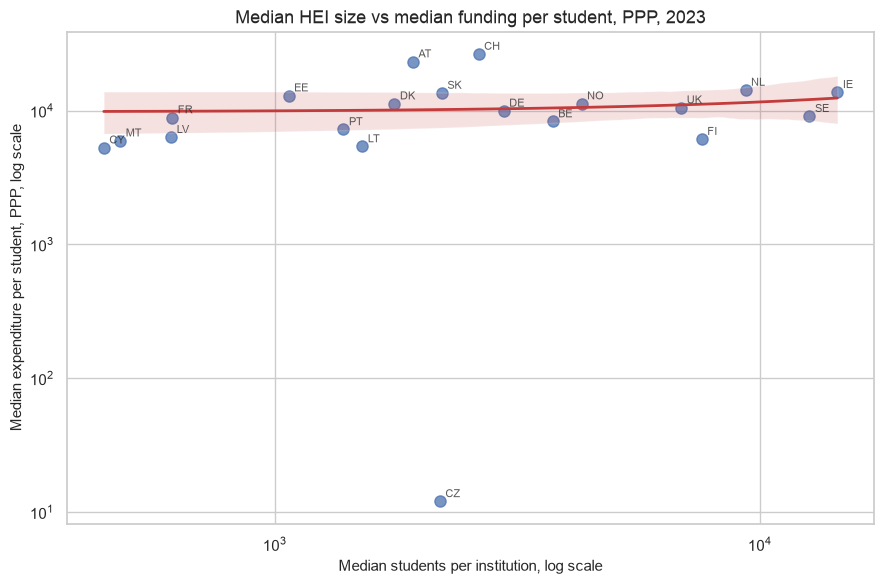

In [20]:
eligible_year_counts = (
    median_students_funding_sample_filtered.groupby("year")["country_code"]
    .nunique()
    .sort_index()
)
scatter_year = (
    int(eligible_year_counts[eligible_year_counts >= 8].index.max())
    if (eligible_year_counts >= 8).any()
    else int(eligible_year_counts.idxmax())
)
scatter_latest = median_students_funding_sample_filtered[
    median_students_funding_sample_filtered["year"].eq(scatter_year)
].copy()

fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    data=scatter_latest,
    x="median_students_per_institution",
    y="median_funding_per_student_ppp",
    scatter_kws={"s": 65, "alpha": 0.75},
    line_kws={"color": "#C43B3B", "linewidth": 2},
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(f"Median HEI size vs median funding per student, PPP, {scatter_year}")
ax.set_xlabel("Median students per institution, log scale")
ax.set_ylabel("Median expenditure per student, PPP, log scale")

for _, row in scatter_latest.iterrows():
    ax.annotate(
        row["country_code"],
        (row["median_students_per_institution"], row["median_funding_per_student_ppp"]),
        textcoords="offset points",
        xytext=(4, 3),
        fontsize=8,
        alpha=0.75,
    )

fig.tight_layout()
figure_output_path = save_figure("03_median_students_funding_per_student_correlation.png", fig=fig)
plt.show()


In [21]:
selected_funding_scatter_year_countries = scatter_latest[
    [
        "country_code",
        "year",
        "records_count",
        "institutions_count",
        "institutions_with_student_data",
        "institutions_with_funding_ppp_data",
        "median_students_per_institution",
        "median_funding_per_student_ppp",
    ]
].sort_values("country_code")

high_funding_countries = scatter_latest.nlargest(
    10,
    "median_funding_per_student_ppp",
)[
    [
        "country_code",
        "year",
        "records_count",
        "institutions_count",
        "institutions_with_student_data",
        "institutions_with_funding_ppp_data",
        "median_students_per_institution",
        "median_funding_per_student_ppp",
    ]
]

(
    selected_funding_scatter_year_countries,
    high_funding_countries,
    country_year_output_path.relative_to(PROJECT_ROOT),
    correlation_output_path.relative_to(PROJECT_ROOT),
    yearly_correlation_output_path.relative_to(PROJECT_ROOT),
    figure_output_path.relative_to(PROJECT_ROOT),
)


(    country_code  year  records_count  institutions_count  \
 26            AT  2023             76                  76   
 36            BE  2023            143                 143   
 56            CH  2023             43                  43   
 66            CY  2023             31                  31   
 76            CZ  2023             54                  54   
 86            DE  2023            400                 400   
 96            DK  2023             40                  40   
 106           EE  2023             18                  18   
 126           FI  2023             38                  38   
 135           FR  2023            816                 816   
 175           IE  2023             18                  18   
 215           LT  2023             34                  34   
 235           LV  2023             42                  42   
 255           MT  2023             13                  13   
 265           NL  2023             57                  57   
 275    

## 12.2. Медіанний розмір ЗВО та медіанна кількість студентів на викладача

Цей підпункт перевіряє, чи пов'язані більші за медіанною чисельністю студентів системи ЗВО з вищим медіанним навантаженням на викладацький FTE. Використовуються останні доступні спостереження за країнами за 2022-2023 роки: якщо доступні обидва роки, вибирається рік із більшою кількістю валідних спостережень, а за рівності - 2023. У підсумковій вибірці 27 країн.

Результат: Pearson `r = 0.2331`, `p = 0.2419`; Spearman `rho = 0.2271`, `p = 0.2546`. Обидва коефіцієнти додатні, але статистично незначущі. Це означає, що за вибраними країнами не можна впевнено стверджувати, що медіанний розмір ЗВО пов'язаний із медіанною кількістю студентів на викладача. Можлива слабка додатна тенденція потребує перевірки на повнішій панелі та з урахуванням структури типів закладів.


In [22]:
correlation_years = [2022, 2023]

correlation_base_df = teacher_ratio_df.loc[
    teacher_ratio_df["year"].isin(correlation_years)
    & teacher_ratio_df["country_code"].notna()
    & teacher_ratio_df["institution_id"].notna()
    & teacher_ratio_df["students_total_calc"].notna()
    & (teacher_ratio_df["students_total_calc"] > 0)
    & teacher_ratio_df["students_per_teacher"].notna()
    & np.isfinite(teacher_ratio_df["students_per_teacher"])
    & (teacher_ratio_df["students_per_teacher"] > 0)
].copy()

correlation_country_year = (
    correlation_base_df.groupby(["country_code", "year"], as_index=False)
    .agg(
        valid_observations=("institution_id", "size"),
        institutions_count=("institution_id", "nunique"),
        median_students_all_heis=("students_total_calc", "median"),
        median_students_per_teacher_all_heis=("students_per_teacher", "median"),
    )
)

correlation_country_year["year_priority"] = correlation_country_year["year"].eq(2023).astype(int)

selected_correlation_year = (
    correlation_country_year.sort_values(
        ["country_code", "valid_observations", "year_priority"],
        ascending=[True, False, False],
    )
    .drop_duplicates("country_code", keep="first")
    .drop(columns="year_priority")
    .rename(columns={"year": "selected_year"})
    .sort_values("country_code")
    .reset_index(drop=True)
)

countries_with_valid_2022_2023 = set(selected_correlation_year["country_code"])
all_countries_in_df = set(df["country_code"].dropna().astype(str))
excluded_countries_no_valid_2022_2023 = sorted(all_countries_in_df - countries_with_valid_2022_2023)

correlation_filter_summary = pd.Series(
    {
        "years_used": "2022-2023",
        "valid_hei_year_observations": len(correlation_base_df),
        "country_year_rows_before_selection": len(correlation_country_year),
        "countries_included": selected_correlation_year["country_code"].nunique(),
        "countries_excluded_no_valid_2022_2023_data": len(excluded_countries_no_valid_2022_2023),
        "countries_selected_2022": int(selected_correlation_year["selected_year"].eq(2022).sum()),
        "countries_selected_2023": int(selected_correlation_year["selected_year"].eq(2023).sum()),
    }
)

correlation_filter_summary


years_used                                    2022-2023
valid_hei_year_observations                        3449
country_year_rows_before_selection                   52
countries_included                                   27
countries_excluded_no_valid_2022_2023_data           13
countries_selected_2022                               5
countries_selected_2023                              22
dtype: object

In [23]:
correlation_output_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "median_students_students_per_teacher_correlation_all_heis_2022_2023.csv"
)

selected_correlation_year.to_csv(
    correlation_output_path,
    sep=";",
    decimal=",",
    index=False,
    float_format="%.4f",
)

selected_correlation_year.head(20)


,country_code,selected_year,valid_observations,institutions_count,median_students_all_heis,median_students_per_teacher_all_heis
0,AT,2023,76,76,1926.206145,13.466882
1,BE,2023,21,21,10060.000000,19.402062
2,CH,2023,43,43,2631.000000,8.403756
3,CY,2023,31,31,444.000000,16.666667
4,CZ,2023,51,51,2179.000000,16.340990
5,DE,2023,396,396,2929.500000,15.301932
6,DK,2023,8,8,17075.000000,9.695128
7,EE,2023,7,7,2835.000000,9.551913
8,ES,2023,89,89,13803.000000,15.919643
9,FI,2023,35,35,8418.000000,18.826592


In [24]:
try:
    from scipy import stats

    pearson_result = stats.pearsonr(
        selected_correlation_year["median_students_all_heis"],
        selected_correlation_year["median_students_per_teacher_all_heis"],
    )
    spearman_result = stats.spearmanr(
        selected_correlation_year["median_students_all_heis"],
        selected_correlation_year["median_students_per_teacher_all_heis"],
    )

    correlation_results = pd.DataFrame(
        {
            "method": ["pearson", "spearman"],
            "correlation": [pearson_result.statistic, spearman_result.statistic],
            "p_value": [pearson_result.pvalue, spearman_result.pvalue],
            "n_countries": [len(selected_correlation_year), len(selected_correlation_year)],
        }
    )
except ImportError:
    correlation_results = pd.DataFrame(
        {
            "method": ["pearson", "spearman"],
            "correlation": [
                selected_correlation_year[
                    ["median_students_all_heis", "median_students_per_teacher_all_heis"]
                ].corr(method="pearson").iloc[0, 1],
                selected_correlation_year[
                    ["median_students_all_heis", "median_students_per_teacher_all_heis"]
                ].corr(method="spearman").iloc[0, 1],
            ],
            "p_value": [np.nan, np.nan],
            "n_countries": [len(selected_correlation_year), len(selected_correlation_year)],
        }
    )

correlation_results


,method,correlation,p_value,n_countries
0,pearson,0.233129,0.241894,27
1,spearman,0.227106,0.254619,27


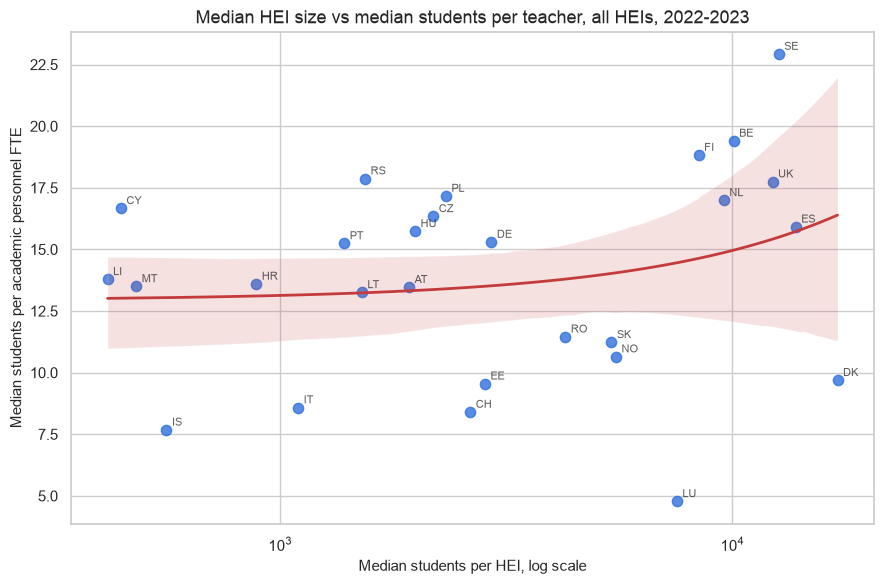

In [25]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    data=selected_correlation_year,
    x="median_students_all_heis",
    y="median_students_per_teacher_all_heis",
    scatter_kws={"s": 55, "alpha": 0.8, "color": "#2F6FDB"},
    line_kws={"color": "#C43B3B", "linewidth": 2},
    ax=ax,
)

for _, row in selected_correlation_year.iterrows():
    ax.annotate(
        row["country_code"],
        (row["median_students_all_heis"], row["median_students_per_teacher_all_heis"]),
        textcoords="offset points",
        xytext=(4, 3),
        fontsize=8,
        alpha=0.75,
    )

ax.set_xscale("log")
ax.set_title("Median HEI size vs median students per teacher, all HEIs, 2022-2023")
ax.set_xlabel("Median students per HEI, log scale")
ax.set_ylabel("Median students per academic personnel FTE")

plt.tight_layout()
save_figure("03_median_students_students_per_teacher_correlation_all_heis_2022_2023.png", fig=fig)
plt.show()


## 12.3. Медіанна кількість студентів на викладача та фінансування на студента

Тут перевіряється зв'язок між медіанним навантаженням студентів на викладача та медіанним фінансуванням на студента. Використовується та сама країнова вибірка 2022-2023 років, що й у підпункті 12.2, але після об'єднання з фінансовими метриками залишаються тільки країни з доступним `median_funding_per_student_ppp`. У підсумковому розрахунку 21 країна.

Результат: Pearson `r = -0.5705`, `p = 0.0069`; Spearman `rho = -0.5351`, `p = 0.0124`. Зв'язок від'ємний і статистично значущий: країни з вищим медіанним навантаженням студентів на викладача зазвичай мають нижче медіанне фінансування на студента в PPP. Це узгоджується з інтерпретацією ресурсної напруженості, але залишається описовим зв'язком: на нього можуть впливати склад систем ЗВО, методологія обліку персоналу та повнота фінансових даних.


In [26]:
teacher_funding_correlation_year = selected_correlation_year.merge(
    country_year_median_size_funding[
        [
            "country_code",
            "year",
            "median_funding_per_student_ppp",
            "institutions_with_funding_ppp_data",
            "funding_ppp_data_coverage",
        ]
    ],
    left_on=["country_code", "selected_year"],
    right_on=["country_code", "year"],
    how="left",
).drop(columns="year")

teacher_funding_correlation_sample = teacher_funding_correlation_year.dropna(
    subset=["median_students_per_teacher_all_heis", "median_funding_per_student_ppp"]
).copy()

try:
    from scipy import stats

    pearson_result = stats.pearsonr(
        teacher_funding_correlation_sample["median_students_per_teacher_all_heis"],
        teacher_funding_correlation_sample["median_funding_per_student_ppp"],
    )
    spearman_result = stats.spearmanr(
        teacher_funding_correlation_sample["median_students_per_teacher_all_heis"],
        teacher_funding_correlation_sample["median_funding_per_student_ppp"],
    )

    teacher_funding_correlation_results = pd.DataFrame(
        {
            "method": ["pearson", "spearman"],
            "correlation": [pearson_result.statistic, spearman_result.statistic],
            "p_value": [pearson_result.pvalue, spearman_result.pvalue],
            "n_countries": [
                len(teacher_funding_correlation_sample),
                len(teacher_funding_correlation_sample),
            ],
        }
    )
except ImportError:
    teacher_funding_correlation_results = pd.DataFrame(
        {
            "method": ["pearson", "spearman"],
            "correlation": [
                teacher_funding_correlation_sample[
                    ["median_students_per_teacher_all_heis", "median_funding_per_student_ppp"]
                ].corr(method="pearson").iloc[0, 1],
                teacher_funding_correlation_sample[
                    ["median_students_per_teacher_all_heis", "median_funding_per_student_ppp"]
                ].corr(method="spearman").iloc[0, 1],
            ],
            "p_value": [np.nan, np.nan],
            "n_countries": [
                len(teacher_funding_correlation_sample),
                len(teacher_funding_correlation_sample),
            ],
        }
    )

teacher_funding_correlation_output_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "median_students_per_teacher_funding_per_student_correlation_all_heis_2022_2023.csv"
)

teacher_funding_correlation_results.to_csv(
    teacher_funding_correlation_output_path,
    sep=";",
    decimal=",",
    index=False,
    float_format="%.4f",
)

teacher_funding_correlation_results


,method,correlation,p_value,n_countries
0,pearson,-0.570522,0.006919,21
1,spearman,-0.535065,0.012442,21


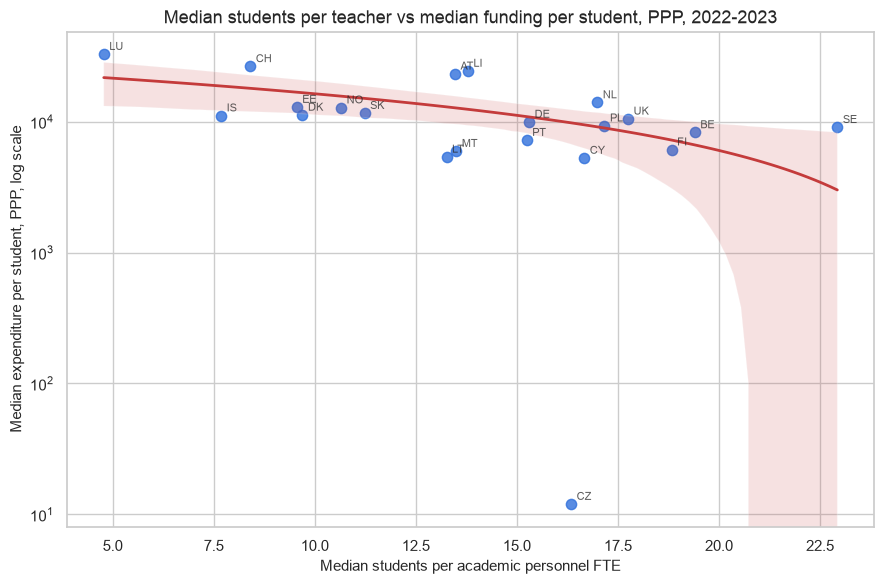

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    data=teacher_funding_correlation_sample,
    x="median_students_per_teacher_all_heis",
    y="median_funding_per_student_ppp",
    scatter_kws={"s": 55, "alpha": 0.8, "color": "#2F6FDB"},
    line_kws={"color": "#C43B3B", "linewidth": 2},
    ax=ax,
)

for _, row in teacher_funding_correlation_sample.iterrows():
    ax.annotate(
        row["country_code"],
        (row["median_students_per_teacher_all_heis"], row["median_funding_per_student_ppp"]),
        textcoords="offset points",
        xytext=(4, 3),
        fontsize=8,
        alpha=0.75,
    )

ax.set_yscale("log")
ax.set_title("Median students per teacher vs median funding per student, PPP, 2022-2023")
ax.set_xlabel("Median students per academic personnel FTE")
ax.set_ylabel("Median expenditure per student, PPP, log scale")

plt.tight_layout()
save_figure("03_students_per_teacher_funding_per_student_correlation_all_heis_2022_2023.png", fig=fig)
plt.show()


In [28]:
selected_2022_countries = selected_correlation_year.loc[
    selected_correlation_year["selected_year"].eq(2022),
    [
        "country_code",
        "selected_year",
        "valid_observations",
        "institutions_count",
        "median_students_all_heis",
        "median_students_per_teacher_all_heis",
    ],
].sort_values("country_code")

high_ratio_countries = selected_correlation_year.nlargest(
    10,
    "median_students_per_teacher_all_heis",
)[
    [
        "country_code",
        "selected_year",
        "valid_observations",
        "institutions_count",
        "median_students_all_heis",
        "median_students_per_teacher_all_heis",
    ]
]

selected_2022_countries, high_ratio_countries, correlation_output_path.relative_to(PROJECT_ROOT)


(   country_code  selected_year  valid_observations  institutions_count  \
 18           NL           2022                  54                  54   
 19           NO           2022                  30                  30   
 20           PL           2022                 263                 263   
 23           RS           2022                  39                  39   
 25           SK           2022                  20                  20   
 
     median_students_all_heis  median_students_per_teacher_all_heis  
 18                    9570.0                             16.989655  
 19                    5526.0                             10.650926  
 20                    2325.0                             17.166667  
 23                    1540.0                             17.875000  
 25                    5397.5                             11.231481  ,
    country_code  selected_year  valid_observations  institutions_count  \
 24           SE           2023                  39 